In [8]:
import numpy as np
from scipy.optimize import minimize_scalar

def expected_combos(p, n=50):
    """Вычисляет ожидаемое количество комбо (серий из ≥3 успехов подряд) для данных p и n."""
    # Для серий длины 3, 4, ..., n
    # Ожидаемое количество комбо = сумма по k от 3 до n (вероятность комбо длины k) * количество возможных позиций
    
    total = 0.0
    for k in range(3, n+1):
        # Количество возможных серий длины k
        num_series = n - k + 1
        # Вероятность что конкретная серия длины k состоит из успехов
        prob_series = p**k
        total += num_series * prob_series
        
        # Вычитаем перекрывающиеся серии (чтобы не считать их несколько раз)
        # Это сложная часть, но для оценки можно использовать приближение
        # Для точного решения нужно использовать более сложную формулу
        
    # Более точный подход: использовать рекуррентные соотношения
    # Инициализируем массив для динамического программирования
    # dp[i][j] - вероятность иметь j последовательных успехов в позиции i
    
    # Альтернативный (более точный) метод:
    # Используем марковскую цепь для подсчета ожидаемого числа комбо
    # Состояния: 0 (неудача или начало), 1, 2, 3+ (комбо)
    
    # Инициализация
    E = np.zeros(4)  # Ожидаемое количество комбо для каждого состояния
    trans = np.zeros((4, 4))  # Матрица переходов
    
    # Вероятности переходов
    trans[0, 0] = 1 - p  # 0 -> 0 (неудача)
    trans[0, 1] = p       # 0 -> 1 (успех)
    
    trans[1, 0] = 1 - p   # 1 -> 0
    trans[1, 2] = p       # 1 -> 2
    
    trans[2, 0] = 1 - p   # 2 -> 0
    trans[2, 3] = p       # 2 -> 3 (начало комбо)
    
    trans[3, 0] = 1 - p   # 3+ -> 0
    trans[3, 3] = p       # 3+ -> 3+ (продолжение комбо)
    
    # Для каждого перехода в состояние 3 мы получаем +1 к комбо если это был переход 2->3
    total_combos = 0
    current = np.array([1, 0, 0, 0])  # Начинаем в состоянии 0
    
    for _ in range(n):
        # Количество новых комбо - это количество переходов 2->3
        new_combos = current[2] * p
        total_combos += new_combos
        
        # Обновляем состояния
        new_current = np.zeros(4)
        for from_state in range(4):
            for to_state in range(4):
                new_current[to_state] += current[from_state] * trans[from_state, to_state]
        current = new_current
    
    return total_combos

# Оптимизация p
result = minimize_scalar(lambda p: -expected_combos(p), bounds=(0, 1), method='bounded')
optimal_p = result.x
max_expected_combos = -result.fun

print(f"Оптимальная вероятность p: {optimal_p:.10f}")
print(f"Максимальное ожидаемое количество комбо: {max_expected_combos:.4f}")

Оптимальная вероятность p: 0.7659575038
Максимальное ожидаемое количество комбо: 5.3926


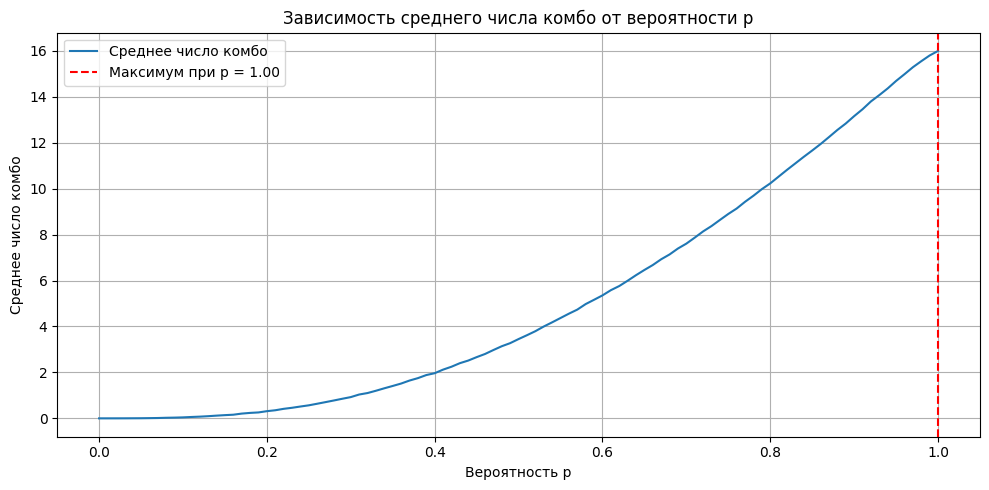

(np.float64(1.0), np.float64(16.0))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
n_checkpoints = 50
n_trials = 10000
p_values = np.linspace(0, 1, 101)
combo_means = []

def count_combos(run):
    i = 0
    count = 0
    while i <= len(run) - 3:
        if run[i] == 1 and run[i+1] == 1 and run[i+2] == 1:
            count += 1
            i += 3  # неперекрывающиеся
        else:
            i += 1
    return count

# Основной цикл по p
for p in p_values:
    combos = []
    for _ in range(n_trials):
        run = np.random.rand(n_checkpoints) < p
        combos.append(count_combos(run))
    combo_means.append(np.mean(combos))

# Найдём максимальное значение
best_p = p_values[np.argmax(combo_means)]
best_mean = max(combo_means)

# Построим график
plt.figure(figsize=(10, 5))
plt.plot(p_values, combo_means, label="Среднее число комбо")
plt.axvline(best_p, color='red', linestyle='--', label=f"Максимум при p = {best_p:.2f}")
plt.xlabel("Вероятность p")
plt.ylabel("Среднее число комбо")
plt.title("Зависимость среднего числа комбо от вероятности p")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_p, best_mean


In [3]:
import numpy as np

# Параметры задачи
c = 50  # Длина пути
num_simulations = 10000  # Количество симуляций для каждого p
p_values = np.arange(0, 1.01, 0.01)  # Значения p от 0 до 1 с шагом 0.01

# Функция для подсчёта комбо в последовательности
def count_combos(sequence):
    combos = 0
    i = 0
    while i < len(sequence):
        if sequence[i] == 1:
            # Нашли начало потенциального комбо
            length = 0
            while i < len(sequence) and sequence[i] == 1:
                length += 1
                i += 1
            # Если длина >= 3, считаем количество комбо
            if length >= 3:
                # В последовательности длиной k (k >= 3) есть (k-2) комбо
                # Например, в 1111 (длина 4) есть комбо: 111 (1-3), 111 (2-4) — итого 2 комбо
                combos += (length - 2)
        else:
            i += 1
    return combos

# Основной цикл для перебора p
max_expected_combos = 0
best_p = 0

for p in p_values:
    total_combos = 0
    # Симуляция для текущего p
    for _ in range(num_simulations):
        # Генерируем последовательность
        sequence = np.random.choice([0, 1], size=c, p=[1-p, p])
        # Считаем комбо
        combos = count_combos(sequence)
        total_combos += combos
    
    # Среднее количество комбо для текущего p
    expected_combos = total_combos / num_simulations
    
    # Обновляем максимум
    if expected_combos > max_expected_combos:
        max_expected_combos = expected_combos
        best_p = p

# Вывод результата
print(f"Максимальное среднее количество комбо: {max_expected_combos:.2f}")
print(f"Оптимальное значение p: {best_p:.2f}")

Максимальное среднее количество комбо: 48.00
Оптимальное значение p: 1.00


In [4]:
import numpy as np

def simulate_combos(p, num_checkpoints=50, num_simulations=10000):
    total_combos = 0
    for _ in range(num_simulations):
        successes = np.random.random(num_checkpoints) < p
        combo_count = 0
        current_streak = 0
        for success in successes:
            if success:
                current_streak += 1
            else:
                if current_streak >= 3:
                    combo_count += 1
                current_streak = 0
        if current_streak >= 3:
            combo_count += 1
        total_combos += combo_count
    return total_combos / num_simulations

# Поиск оптимального p
p_values = np.linspace(0, 1, 101)
average_combos = [simulate_combos(p) for p in p_values]
optimal_p = p_values[np.argmax(average_combos)]

print(f"Оптимальное значение p: {optimal_p}")

Оптимальное значение p: 0.75


In [5]:
import numpy as np

def count_combos(successes):
    combo_count = 0
    current_streak = 0
    
    for success in successes:
        if success:
            current_streak += 1
        else:
            if current_streak >= 3:
                combo_count += 1
            current_streak = 0
    
    # Проверяем последнюю серию
    if current_streak >= 3:
        combo_count += 1
    
    return combo_count

def simulate_combos(p, n=50, trials=10000):
    total_combos = 0
    for _ in range(trials):
        successes = np.random.random(n) < p
        total_combos += count_combos(successes)
    return total_combos / trials

# Перебираем p от 0 до 1 с шагом 0.01
p_values = np.arange(0, 1.01, 0.01)
combo_means = []

for p in p_values:
    mean = simulate_combos(p)
    combo_means.append(mean)
    print(f"p = {p:.2f}, среднее комбо = {mean:.4f}")

# Находим p с максимальным средним количеством комбо
best_p = p_values[np.argmax(combo_means)]
print(f"\nОптимальное p: {best_p:.2f}")

p = 0.00, среднее комбо = 0.0000
p = 0.01, среднее комбо = 0.0000
p = 0.02, среднее комбо = 0.0002
p = 0.03, среднее комбо = 0.0009
p = 0.04, среднее комбо = 0.0028
p = 0.05, среднее комбо = 0.0061
p = 0.06, среднее комбо = 0.0090
p = 0.07, среднее комбо = 0.0131
p = 0.08, среднее комбо = 0.0201
p = 0.09, среднее комбо = 0.0291
p = 0.10, среднее комбо = 0.0410
p = 0.11, среднее комбо = 0.0580
p = 0.12, среднее комбо = 0.0739
p = 0.13, среднее комбо = 0.0963
p = 0.14, среднее комбо = 0.1159
p = 0.15, среднее комбо = 0.1323
p = 0.16, среднее комбо = 0.1640
p = 0.17, среднее комбо = 0.1877
p = 0.18, среднее комбо = 0.2199
p = 0.19, среднее комбо = 0.2704
p = 0.20, среднее комбо = 0.3099
p = 0.21, среднее комбо = 0.3433
p = 0.22, среднее комбо = 0.4069
p = 0.23, среднее комбо = 0.4475
p = 0.24, среднее комбо = 0.5017
p = 0.25, среднее комбо = 0.5663
p = 0.26, среднее комбо = 0.6251
p = 0.27, среднее комбо = 0.6945
p = 0.28, среднее комбо = 0.7666
p = 0.29, среднее комбо = 0.8342
p = 0.30, 

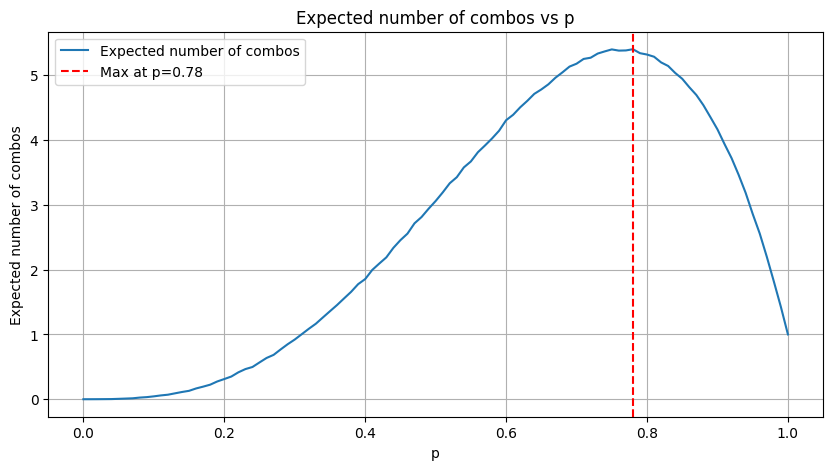

Максимум достигается при p = 0.780, ожидаемое число комбо = 5.399


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def count_combos(seq):
    count = 0
    i = 0
    while i < len(seq):
        if seq[i] == 1:
            start = i
            while i < len(seq) and seq[i] == 1:
                i += 1
            length = i - start
            if length >= 3:
                count += 1
        else:
            i += 1
    return count

# Параметры
n = 50
num_trials = 10000
p_values = np.linspace(0, 1, 101)
expected_combos = []

# Симуляция
for p in p_values:
    combos = 0
    for _ in range(num_trials):
        seq = np.random.binomial(1, p, size=n)
        combos += count_combos(seq)
    expected_combos.append(combos / num_trials)

# Найдём максимум
max_combos = max(expected_combos)
best_p = p_values[np.argmax(expected_combos)]

# Построим график
plt.figure(figsize=(10, 5))
plt.plot(p_values, expected_combos, label='Expected number of combos')
plt.axvline(best_p, color='r', linestyle='--', label=f'Max at p={best_p:.2f}')
plt.title('Expected number of combos vs p')
plt.xlabel('p')
plt.ylabel('Expected number of combos')
plt.legend()
plt.grid(True)
plt.show()

print(f"Максимум достигается при p = {best_p:.3f}, ожидаемое число комбо = {max_combos:.3f}")


In [7]:
import numpy as np

def count_combos(successes):
    combo_count = 0
    current_streak = 0
    
    for success in successes:
        if success:
            current_streak += 1
        else:
            if current_streak >= 3:
                combo_count += 1
            current_streak = 0
    
    if current_streak >= 3:
        combo_count += 1
    
    return combo_count

def expected_combos(p, n=50, trials=100000):
    total_combos = 0
    for _ in range(trials):
        successes = np.random.random(n) < p
        total_combos += count_combos(successes)
    return total_combos / trials

def golden_section_search(func, a, b, tol=1e-9):
    gr = (np.sqrt(5) + 1) / 2  # Золотое сечение
    
    c = b - (b - a) / gr
    d = a + (b - a) / gr
    
    while abs(c - d) > tol:
        if func(c) < func(d):
            b = d
        else:
            a = c
        
        c = b - (b - a) / gr
        d = a + (b - a) / gr
    
    return (b + a) / 2

# Оптимизация p
best_p = golden_section_search(lambda p: expected_combos(p), 0, 1)
print(f"Оптимальное p: {best_p:.10f}")

Оптимальное p: 0.0074501470
